### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [6]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv)
print(arxiv.name)

api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)
arxiv


In [7]:
import arxiv as arxiv_module

# Ensure compatibility across arxiv package versions while avoiding recursion:
# Save original methods if present so our fallbacks call the originals (not any patched wrappers).
if hasattr(arxiv_module.Search, "results") and not hasattr(arxiv_module.Search, "__original_results__"):
    arxiv_module.Search.__original_results__ = arxiv_module.Search.results
if hasattr(arxiv_module.Search, "__iter__") and not hasattr(arxiv_module.Search, "__original_iter__"):
    arxiv_module.Search.__original_iter__ = arxiv_module.Search.__iter__

# If Search lacks __iter__ but has an original results, add a safe __iter__
if not hasattr(arxiv_module.Search, "__iter__") and hasattr(arxiv_module.Search, "__original_results__"):
    def __iter__(self):
        return iter(arxiv_module.Search.__original_results__(self))
    arxiv_module.Search.__iter__ = __iter__
# If Search lacks results but has an original __iter__, add a safe results
elif not hasattr(arxiv_module.Search, "results") and hasattr(arxiv_module.Search, "__original_iter__"):
    def results(self):
        return list(arxiv_module.Search.__original_iter__(self))
    arxiv_module.Search.results = results

print(arxiv.invoke("Attention iss all you need"))

AttributeError: 'Search' object has no attribute 'results'

In [8]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [9]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [10]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [11]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [13]:
tavily.invoke("Provide me the recent AI news for July 4th 2026")

[{'title': 'AI News Today July 4 2026: 15 Biggest Stories',
  'url': 'https://www.buildfastwithai.com/blogs/ai-news-today-july-4-2026',
  'content': "On America's Independence Day, July 4, 2026, the AI industry is not taking a holiday. Grok 4.5 is in private beta at SpaceX and Tesla. A 1.6-trillion-parameter Chinese model trained entirely on domestic chips has just been open-sourced under MIT. Anthropic is closing loopholes that let Chinese companies access Claude through Singapore subsidiaries and VPNs. Court emails show the Pentagon demanded Anthropic accept autonomous weapons as a condition of its government contracts. And OpenAI is reportedly offering the US government a 5% stake in the company as part of its IPO strategy. Here are the 15 stories that define July 4, 2026. For continuous coverage of the full AI frontier, the AI Industry News and Trends hub at Build Fast with AI is your running reference. [...] OpenAI has reportedly proposed to the US government a structure where Was

In [14]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [18]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [19]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "What is the recent AI News". They likely want a summary of recent AI news. Need to browse recent news. Use tavily_search_results_json with query "recent AI news July 2026" or similar.', 'tool_calls': [{'id': 'fc_385a2cec-5ed5-4f3b-ace3-f7820abae3b7', 'function': {'arguments': '{"query":"AI news July 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 291, 'total_tokens': 375, 'completion_time': 0.175470495, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.011422514, 'prompt_tokens_details': None, 'queue_time': 0.286553842, 'total_time': 0.186893009}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5781dfb07c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f332a-8f9c-72c2-a814-1186f528b033-0', tool_calls=[

In [20]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news July 2024'},
  'id': 'fc_82d53cff-6b70-494e-bdee-96ca76195e38',
  'type': 'tool_call'}]

In [21]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

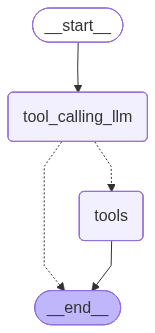

In [23]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

AttributeError: 'Search' object has no attribute 'results'

In [21]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_vfzn)
 Call ID: call_vfzn
  Args:
    query: top 10 recent AI news for March 3rd 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://medium.com/@abhishekmonpara198/weekly-tech-talk-march-3rd-2025-stay-informed-about-the-most-recent-updates-in-the-industry-4d0f4519891d", "content": "A startup, Akool, upgrades Akool Streaming Avatars by connecting them with AI models and adding advanced video generation tech integrating with large language models (LLMs). According to recently published data from Chinese AI provider Deepseek, AI language models have the potential to generate significant profit margins, even when priced well below that of OpenA

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_31ew)
 Call ID: call_31ew
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
